LSTM ATTEMPT AT FORECASTING BILLBOARD POSITION WITH PREVIOUS POSITIONS AND METADATA

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.losses import Huber
from keras.models import load_model

import sys
sys.path.insert(0, '../../Functions')
from plot_placement import plot_song_prediction_comparison_lstm
from lstm_model import build_and_evaluate_model

In [48]:
SEQ_LEN = 4

In [49]:
data_original = pd.read_csv("../../Data/processed_forecast_data.csv")


data_original.head()


,Date,Song,Artist,Rank,Last Week,Weeks in Charts,Normalized Title,Danceability,Energy,Key,...,Duration_ms,Time_signature,Chorus_hit,Sections,rank_change,target_next_rank,rolling_avg_4_weeks,rolling_avg_all_time,rolling_std_4_weeks,rolling_std_all_time
0,1958-12-17,Jingle Bell Rock,Bobby Helms,57,NaN,NaN,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,NaN,35.0,57.000000,57.000000,NaN,NaN
1,1958-12-24,Jingle Bell Rock,Bobby Helms,35,57.0,2.0,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,22.0,45.0,46.000000,46.000000,15.556349,15.556349
2,1958-12-31,Jingle Bell Rock,Bobby Helms,45,35.0,3.0,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,-10.0,70.0,45.666667,45.666667,11.015141,11.015141
3,1959-01-07,Jingle Bell Rock,Bobby Helms,70,45.0,4.0,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,-25.0,69.0,51.750000,51.750000,15.129992,15.129992
4,1960-12-07,Rockin' Around The Christmas Tree,Brenda Lee,64,NaN,NaN,rockin around the christmas tree,0.589,0.472,8,...,126267,4,33.91817,6,NaN,26.0,64.000000,64.000000,NaN,NaN


In [50]:
#adjust data for LSTM
data_original['is_debut'] = data_original['Last Week'].isna().astype(int)
data_original['Last Week'] = data_original['Last Week'].fillna(101)
data_original['Weeks in Charts'] = data_original['Weeks in Charts'].fillna(1)
data_original['Date'] = pd.to_datetime(data_original['Date'])
data_original['rolling_std_4_weeks'] = data_original['rolling_std_4_weeks'].fillna(0)
data_original['rolling_std_all_time'] = data_original['rolling_std_all_time'].fillna(0)
data_original['rank_change'] = data_original['rank_change'].fillna(0)

In [51]:
#prepare lists of features
all_audio_features = ['Instrumentalness', 'Danceability', 'Acousticness',
                      'Duration_ms', 'Energy', 'Valence', 'Loudness',
                      'Speechiness', 'Key', 'Mode', 'Time_signature']
audio_features = ['Instrumentalness', 'Danceability', 'Acousticness', 'Duration_ms', 'Energy', 'Valence']
all_features = ['Date', 'Song', 'Artist', 'Rank', 'Last Week', 'Weeks in Charts', 
                'Normalized Title', 'rank_change', 'rolling_avg_4_weeks', 'rolling_avg_all_time', 
                'rolling_std_4_weeks', 'rolling_std_all_time', 'target_next_rank'] + all_audio_features
features = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] + all_audio_features

In [52]:
features_with_nan = data_original[features].isna().sum()
print(features_with_nan[features_with_nan > 0])
data_original[features] = data_original[features].fillna(0)

Series([], dtype: int64)


In [53]:
groups = data_original.groupby(['Song', 'Artist'])

X = []
y = []
target_dates = []
meta = []

for (song, artist), group in groups:
    group = group.sort_values('Date')

    data = group[features].values
    ranks = group['Rank'].values
    dates = group['Date'].values

    for i in range(len(group) - SEQ_LEN):
        X_seq = data[i:i+SEQ_LEN]
        y_target = ranks[i+SEQ_LEN]
        target_date = dates[i+SEQ_LEN]

        X.append(X_seq)
        y.append(y_target)
        target_dates.append(target_date)

        meta.append({
            'Song': song,
            'Artist': artist,
            'Date': target_date,
            'target_next_rank': y_target
        })

X = np.array(X)
y = np.array(y)
target_dates = np.array(target_dates)

meta = pd.DataFrame(meta)

In [54]:
#split into train and test based on date
target_dates = pd.to_datetime(target_dates)
threshold_date = pd.to_datetime("2014-01-01")

train_mask = target_dates < threshold_date
test_mask = target_dates >= threshold_date

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

test_meta = meta[test_mask].reset_index(drop=True)

In [55]:
#check shapes
print(X.shape, y.shape)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(101726, 4, 19) (101726,)
(80632, 4, 19) (80632,)
(21094, 4, 19) (21094,)


In [56]:
#scale features
scaler = MinMaxScaler()
samples_train, timesteps, features_count = X_train.shape
samples_test = X_test.shape[0]

X_train_2d = X_train.reshape(-1, features_count)
X_test_2d = X_test.reshape(-1, features_count)

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train = X_train_scaled.reshape(samples_train, timesteps, features_count)
X_test = X_test_scaled.reshape(samples_test, timesteps, features_count)



In [57]:
#scale target if needed

y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

In [58]:
#build model
model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, features_count)),
    Dense(32, activation='relu'),
    Dense(1)
])

c:\Users\Marcel\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [59]:
#compile model

model.compile(
    optimizer='adam',
    loss=Huber(delta=1.0),
    metrics=['mae']
)

In [60]:
#train model
history = model.fit(
    X_train,
    y_train_scaled,
    validation_data=(X_test, y_test_scaled),
    epochs=20,
    batch_size=32
)

Epoch 1/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0031 - mae: 0.0508 - val_loss: 0.0030 - val_mae: 0.0494
Epoch 2/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0018 - mae: 0.0407 - val_loss: 0.0030 - val_mae: 0.0503
Epoch 3/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0017 - mae: 0.0400 - val_loss: 0.0029 - val_mae: 0.0501
Epoch 4/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0017 - mae: 0.0396 - val_loss: 0.0028 - val_mae: 0.0480
Epoch 5/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0017 - mae: 0.0391 - val_loss: 0.0026 - val_mae: 0.0469
Epoch 6/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0016 - mae: 0.0390 - val_loss: 0.0028 - val_mae: 0.0482
Epoch 7/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0016 - mae: 0.0388 - val_loss: 0.0027 - val_mae: 0.0469
Epoch 8/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0016 - mae: 0.0386 - val_loss: 0.0027 - val_mae: 0.0469
Epoch 9/20
2520/2520 ━━━━━━━━━━━━━━━━━━━

In [61]:
#evaluate model
loss, mae = model.evaluate(X_test, y_test_scaled)
print(loss, mae)

660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0028 - mae: 0.0486
0.0027682622894644737 0.04863304644823074


In [62]:
y_pred_scaled = model.predict(X_test)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_test.reshape(-1, 1)

660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 908us/step


In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4.814671039581299
RMSE: 7.366372962493726
MAE: 4.814671039581299
RMSE: 7.366372962493726


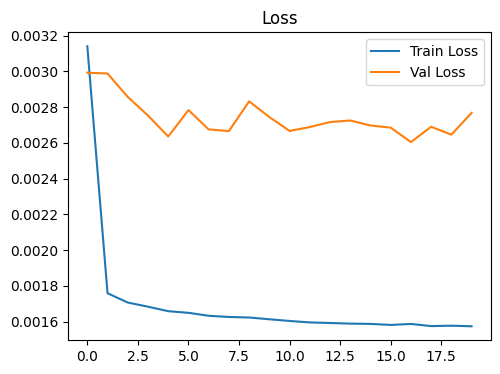

In [64]:
#plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

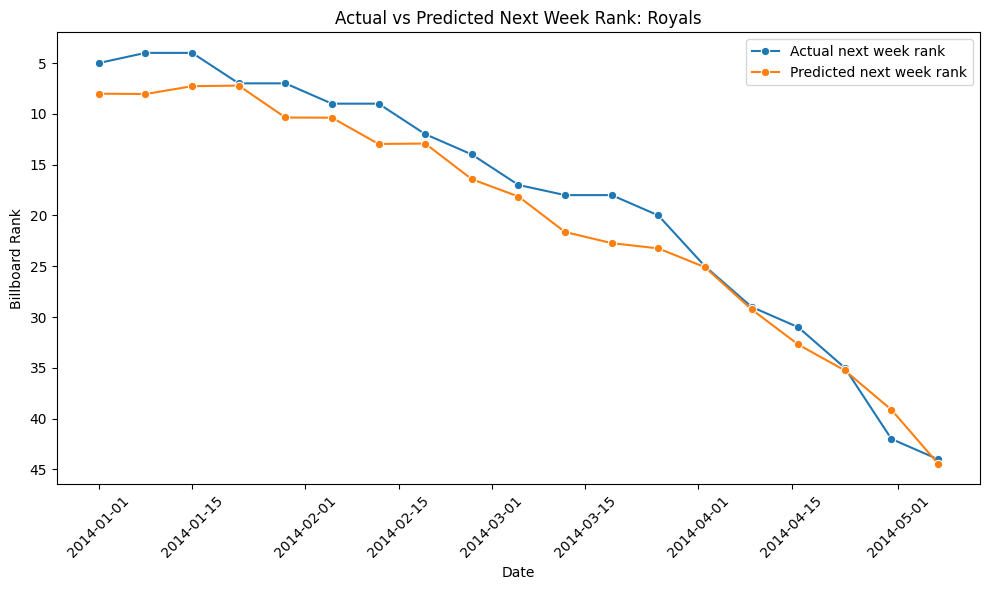

In [65]:

plot_song_prediction_comparison_lstm(
    test_meta,
    song_name="Royals",
    y_pred=y_pred
)

660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step


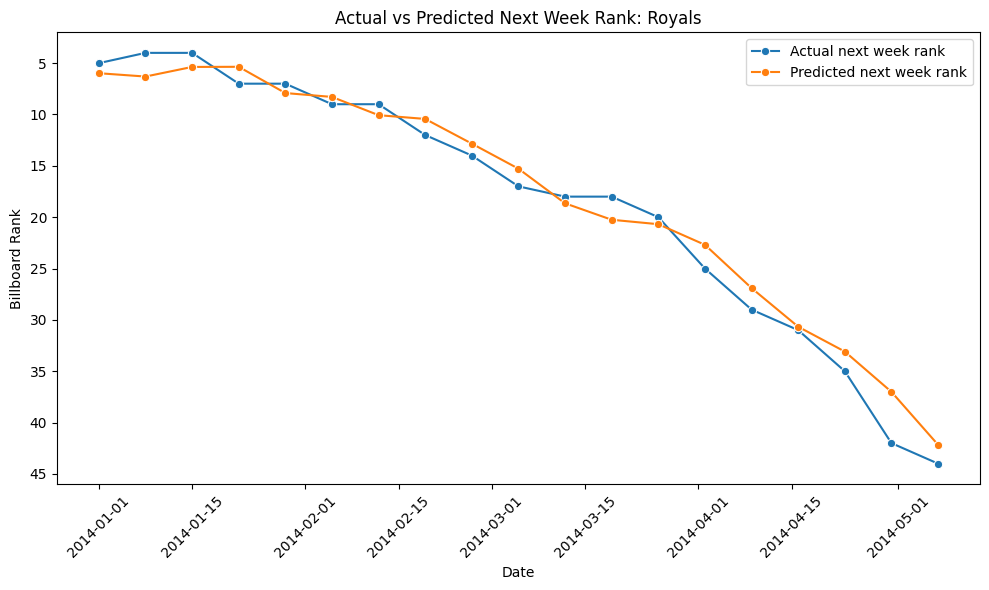

In [66]:
model = load_model('../Models/1st_lstm.keras') 
y_pred_scaled = model.predict(X_test)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

plot_song_prediction_comparison_lstm(
    test_meta,
    song_name="Royals",
    y_pred=y_pred
)

In [67]:
print(train_mask.sum())
print(test_mask.sum())

80632
21094


In [68]:
from pathlib import Path

model_path = Path("../Models/1st_lstm.keras")
model_path.parent.mkdir(parents=True, exist_ok=True)

model.save(str(model_path))

FIRST ABSOLUTELY BASIC LSTM

STRUCTURE
LSTM(64)-DENSE(32)-DENSE(1)

FEATURES
ALL NUMERIC INCLUDED IN DATASET, NO NEW ONES

ERROR
MAE: 4.814671039581299
RMSE: 7.366372962493726

In [69]:
#lets start optimizing by firstly using features from xgboost and then adding audio features one by one to see how they affect the performance
features = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] + ['Duration_ms', 'Loudness', 'Speechiness']



In [70]:
build_and_evaluate_model(features, data_original)




Epoch 1/20


c:\Users\Marcel\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3174/3174 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0025 - mae: 0.0471 - val_loss: 0.0092 - val_mae: 0.0948
Epoch 2/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0019 - mae: 0.0415 - val_loss: 0.0089 - val_mae: 0.0872
Epoch 3/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0019 - mae: 0.0410 - val_loss: 0.0088 - val_mae: 0.0908
Epoch 4/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0405 - val_loss: 0.0088 - val_mae: 0.0869
Epoch 5/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0405 - val_loss: 0.0086 - val_mae: 0.0860
Epoch 6/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0402 - val_loss: 0.0084 - val_mae: 0.0879
Epoch 7/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0401 - val_loss: 0.0079 - val_mae: 0.0813
Epoch 8/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0401 - val_loss: 0.0075 - val_mae: 0.0803
Epoch 9/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/st

6.9273152351379395

FEWER AUDIO FEATURES LSTM

STRUCTURE
LSTM(64)-DENSE(32)-DENSE(1)

FEATURES
BILLBOARD + ROLLING + 'Duration_ms', 'Loudness', 'Speechiness'

ERROR
MAE: 7.817766189575195
RMSE: 12.208566153501158

In [71]:
y_pred_scaled = model.predict(X_test)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_test.reshape(-1, 1)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step
MAE: 4.54744815826416
RMSE: 7.000341952009799
MAE: 4.54744815826416
RMSE: 7.000341952009799
